In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive\Titanic-Dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Data cleaning:

In [7]:
# Drop Cabin column 
df.drop("Cabin", axis=1, inplace=True)

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove remaining rows with null values
df = df.dropna()

# check null values
print("\nFinal Missing Values:")
print(df.isnull().sum())




Final Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


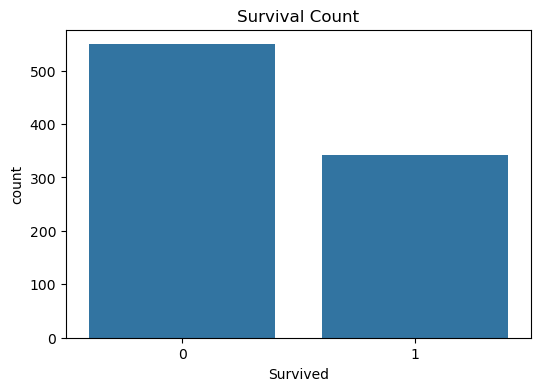

In [8]:
# Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

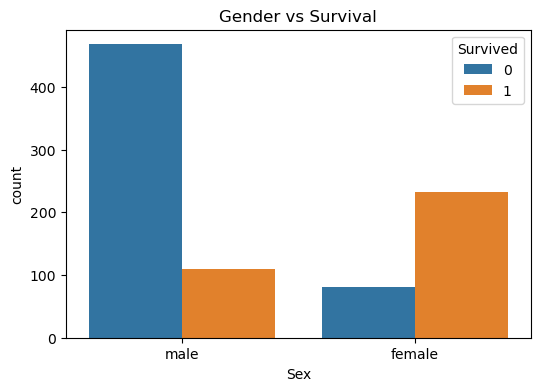

In [9]:
#  Gender vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

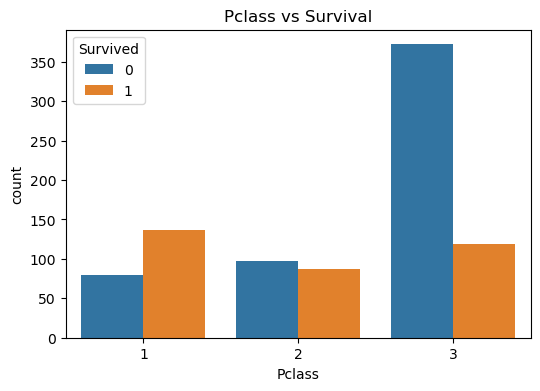

In [10]:
# Passenger Class vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Pclass vs Survival")
plt.show()


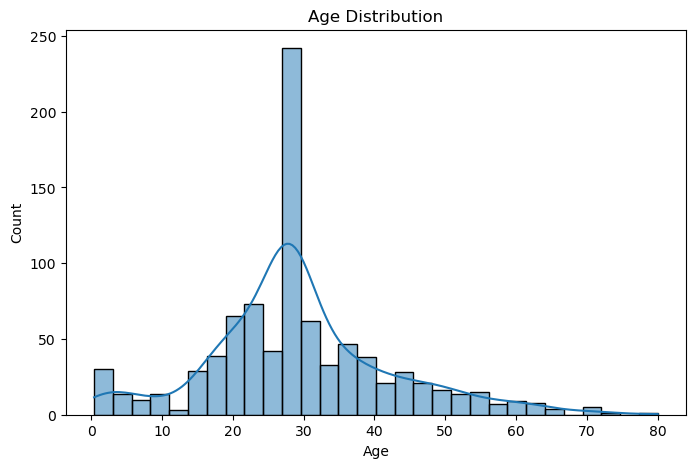

In [11]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

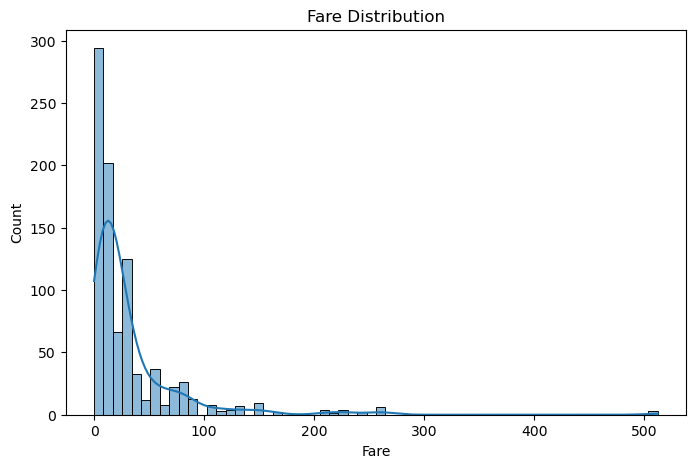

In [12]:
#  Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()

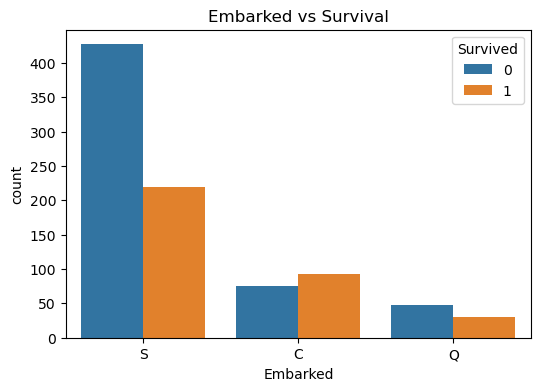

In [13]:
# Embarked vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Embarked vs Survival")
plt.show()

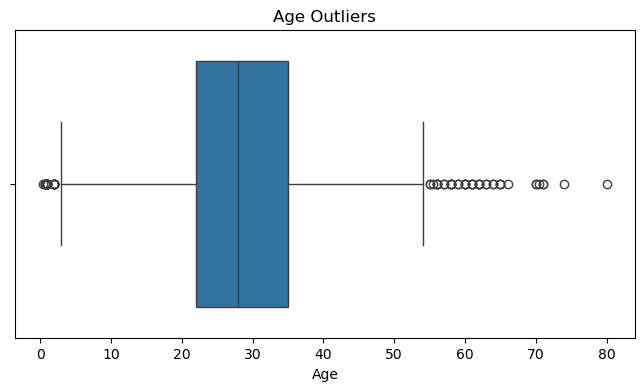

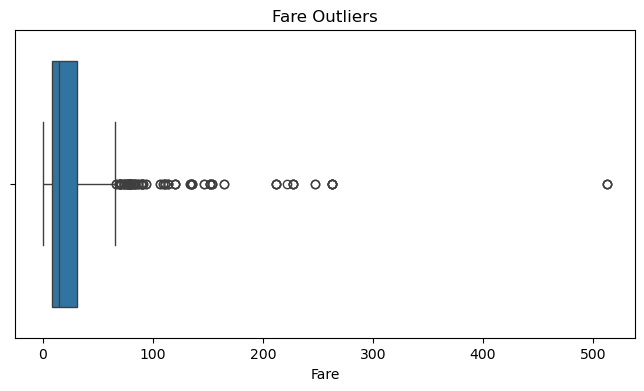

In [14]:
#  Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

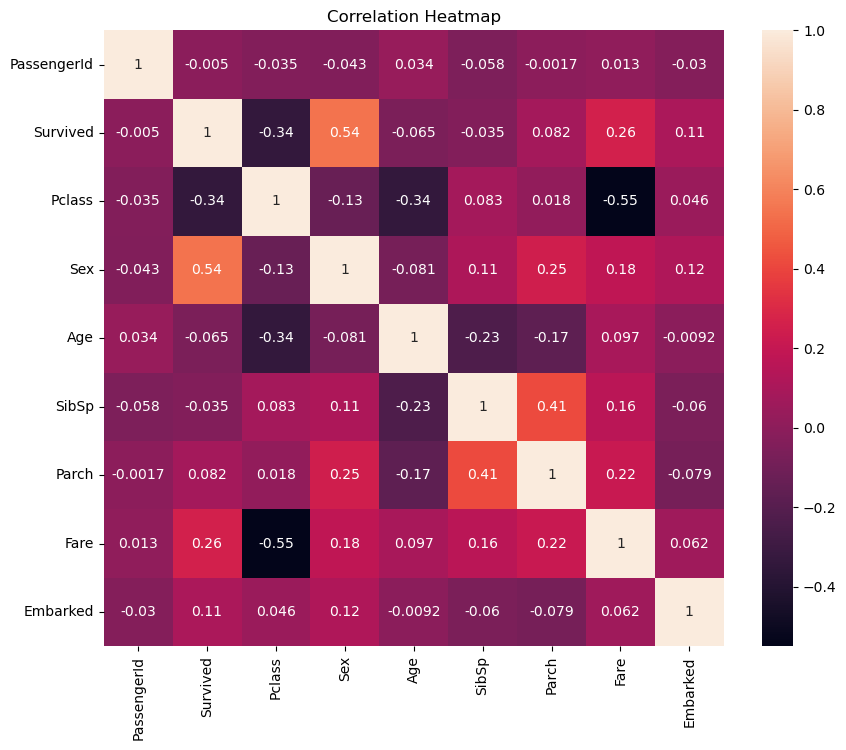

In [15]:
#  Convert categorical data
df["Sex"] = df["Sex"].map({"male":0, "female":1})
df["Embarked"] = df["Embarked"].map({"S":0, "C":1, "Q":2})

#  Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# cleaned dataset
print("Cleaned Data:")
print(df.to_string())

Cleaned Data:
     PassengerId  Survived  Pclass                                                                                Name  Sex    Age  SibSp  Parch              Ticket      Fare  Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    0  22.00      1      0           A/5 21171    7.2500         0
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1  38.00      1      0            PC 17599   71.2833         1
2              3         1       3                                                              Heikkinen, Miss. Laina    1  26.00      0      0    STON/O2. 3101282    7.9250         0
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.00      1      0              113803   53.1000         0
4              5         0       3                           

In [17]:
import os
print(os.getcwd())

C:\Users\hp


In [20]:
import pandas as pd
import sqlite3

# CSV load
df = pd.read_csv(r"C:\Users\hp\Downloads\archive\Titanic-Dataset.csv")

# SQLite database create
conn = sqlite3.connect(r"C:\Users\hp\Titanic.db")

# Table create
df.to_sql("titanic", conn, if_exists="replace", index=False)

conn.commit()
conn.close()

print("Database created successfully!")

Database created successfully!


In [21]:
import sqlite3

conn = sqlite3.connect(r"C:\Users\hp\Titanic.db")

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

conn.close()

[('titanic',)]
